In [1]:
%cd ..

c:\Users\almei\Documents\GitHub\research_ner_leaderboard


In [2]:
from pathlib import Path
import torch
import numpy as np
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification, Trainer, TrainingArguments

from spesia_ner.metrics import compute_metrics
from spesia_ner.datasets import ClinicalRecordsDataset, DataCollatorForMultiLabelTokenClassification
from spesia_ner.trainers import MultiLabelTokenTrainer

model_id = "jhu-clsp/mmBERT-base"
dataset_path = Path("data/Spesia/argilla/annotated_records")

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

labels_to_ignore = ["06. FISH/CISH/SISH", "10. MUTACAO_BRCA1/2"]
labels_to_consider = [
    'DRUG_ALLERGY',          
    'BREAST_SURGERY',        
    'MENOPAUSE_STATUS',      
    'CANCER_FAMILY_HISTORY', 
    'PREGNANCY_PARITY',      
    'PRIOR_RADIOTHERAPY',    
    'HISTOPATHOLOGICAL_TYPE',
    'HER2',                  
    'HORMONE_RECEPTOR',      
    'KI67',                  
    'HEART_DISEASE',         
    'METASTASIS_SITE',       
]

train_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="train",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

val_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="val",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

test_dataset = ClinicalRecordsDataset(
    dataset_path, 
    tokenizer, 
    split="test",
    tags_to_consider=labels_to_consider,
    labels_to_ignore=labels_to_ignore
    )

model = AutoModelForTokenClassification.from_pretrained(model_id, num_labels=train_dataset.num_labels)

Loading all Records: 100%|██████████| 6/6 [00:01<00:00,  4.99it/s]


Ignored labels during data split due to low sample count: ['06. FISH/CISH/SISH', '10. MUTACAO_BRCA1/2']


Loading all Records: 100%|██████████| 6/6 [00:01<00:00,  5.51it/s]


Ignored labels during data split due to low sample count: ['06. FISH/CISH/SISH', '10. MUTACAO_BRCA1/2']


Loading all Records: 100%|██████████| 6/6 [00:01<00:00,  5.46it/s]


Ignored labels during data split due to low sample count: ['06. FISH/CISH/SISH', '10. MUTACAO_BRCA1/2']


Some weights of ModernBertForTokenClassification were not initialized from the model checkpoint at jhu-clsp/mmBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Exception ignored in: <function tqdm.__del__ at 0x00000246FE3E8040>
Traceback (most recent call last):
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [3]:
train_dataset.labels_to_ignore

['06. FISH/CISH/SISH', '10. MUTACAO_BRCA1/2']

In [4]:
train_dataset.get_label_count()

DATE                            1719
DRUG_ALLERGY                    1366
NEGATIVE                        1173
BREAST_SURGERY                  1124
MENOPAUSE_STATUS                 890
CANCER_FAMILY_HISTORY            886
PREGNANCY_PARITY                 875
PRIOR_RADIOTHERAPY               825
HISTOPATHOLOGICAL_TYPE           649
HER2                             628
HORMONE_RECEPTOR                 605
KI67                             500
HEART_DISEASE                    455
NAME                             368
METASTASIS_SITE                  181
LOCATION                         165
01. TIPO_HISTOPATOLOGICO         144
03. RECEPTOR_DE_ESTROGENIO       137
05. RECEPTOR_HER2                134
08. INVASAO_LINFONODAL           132
04. RECEPTOR_DE_PROGESTERONA     131
02. CIRURGIA_PERFORMADA          130
POSITIVE                         130
07. TAMANHO_TUMOR                126
BRCA                              78
09. STATUS_MENOPAUSAL             60
06. FISH/CISH/SISH                16
1

In [5]:
val_dataset.get_label_count()

DATE                            540
DRUG_ALLERGY                    474
NEGATIVE                        406
BREAST_SURGERY                  371
PREGNANCY_PARITY                304
PRIOR_RADIOTHERAPY              298
CANCER_FAMILY_HISTORY           288
MENOPAUSE_STATUS                264
HISTOPATHOLOGICAL_TYPE          222
HORMONE_RECEPTOR                207
HER2                            201
KI67                            164
HEART_DISEASE                   155
NAME                            121
LOCATION                         54
METASTASIS_SITE                  45
02. CIRURGIA_PERFORMADA          42
03. RECEPTOR_DE_ESTROGENIO       42
01. TIPO_HISTOPATOLOGICO         40
09. STATUS_MENOPAUSAL            39
07. TAMANHO_TUMOR                38
05. RECEPTOR_HER2                37
08. INVASAO_LINFONODAL           36
04. RECEPTOR_DE_PROGESTERONA     35
POSITIVE                         24
BRCA                             21
06. FISH/CISH/SISH                8
10. MUTACAO_BRCA1/2         

In [6]:
test_dataset.get_label_count()

DATE                            584
DRUG_ALLERGY                    472
NEGATIVE                        404
BREAST_SURGERY                  377
CANCER_FAMILY_HISTORY           299
PREGNANCY_PARITY                295
MENOPAUSE_STATUS                287
PRIOR_RADIOTHERAPY              272
HISTOPATHOLOGICAL_TYPE          226
HER2                            209
HORMONE_RECEPTOR                199
KI67                            158
HEART_DISEASE                   151
NAME                            122
01. TIPO_HISTOPATOLOGICO         62
LOCATION                         54
METASTASIS_SITE                  50
07. TAMANHO_TUMOR                50
08. INVASAO_LINFONODAL           46
02. CIRURGIA_PERFORMADA          41
BRCA                             35
POSITIVE                         35
03. RECEPTOR_DE_ESTROGENIO       34
04. RECEPTOR_DE_PROGESTERONA     34
05. RECEPTOR_HER2                34
09. STATUS_MENOPAUSAL            23
10. MUTACAO_BRCA1/2               1
06. FISH/CISH/SISH          

In [7]:
from spesia_ner.trainers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./output",
    per_device_train_batch_size=10,
    gradient_accumulation_steps=5,
    num_train_epochs=40,
    learning_rate=1e-5,
    include_for_metrics=['inputs'],
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

data_collator = DataCollatorForMultiLabelTokenClassification(
    pad_token_id=tokenizer.pad_token_id,
    max_length=512,
    num_labels=train_dataset.num_labels
)

trainer = MultiLabelTokenTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(patience=5)],
    pos_weight=train_dataset.pos_weight
)

trainer.train()

Epoch,Training Loss,Validation Loss,Best Threshold,Macro Precision,Macro Recall,Macro F1,Macro Auc,Micro Precision,Micro Recall,Micro F1,Micro Auc
1,1.245200,0.327138,0.460000,0.255566,0.450759,0.296718,0.965047,0.274355,0.494389,0.352882,0.974825
2,0.262600,0.284119,0.360000,0.278583,0.599480,0.366235,0.979423,0.292210,0.666505,0.406293,0.985027
3,0.163000,0.319892,0.330000,0.315828,0.520577,0.382769,0.978397,0.346023,0.612955,0.442338,0.985219
4,0.126900,0.328218,0.450000,0.314105,0.524743,0.388539,0.980062,0.362785,0.599652,0.452071,0.985662
5,0.106000,0.349414,0.330000,0.326214,0.513383,0.393403,0.978947,0.368584,0.606473,0.458509,0.985857
6,0.093000,0.397545,0.440000,0.322435,0.469876,0.370175,0.976660,0.370813,0.584220,0.453673,0.983181
7,0.087300,0.613631,0.120000,0.243495,0.480067,0.308700,0.969782,0.291433,0.565971,0.384749,0.974012


KeyboardInterrupt: 

In [8]:
trainer.eval_dataset = test_dataset
trainer.evaluate()

{'eval_loss': 0.6136305332183838,
 'eval_best_threshold': 0.12,
 'eval_macro_precision': 0.24349487762674984,
 'eval_macro_recall': 0.48006734459710215,
 'eval_macro_f1': 0.3086998631444943,
 'eval_macro_auc': 0.9697818477129867,
 'eval_micro_precision': 0.2914330677682699,
 'eval_micro_recall': 0.5659710615538895,
 'eval_micro_f1': 0.38474898147997855,
 'eval_micro_auc': 0.9740122670874036}

In [9]:
# Get predictions object
pred_output = trainer.predict(test_dataset)

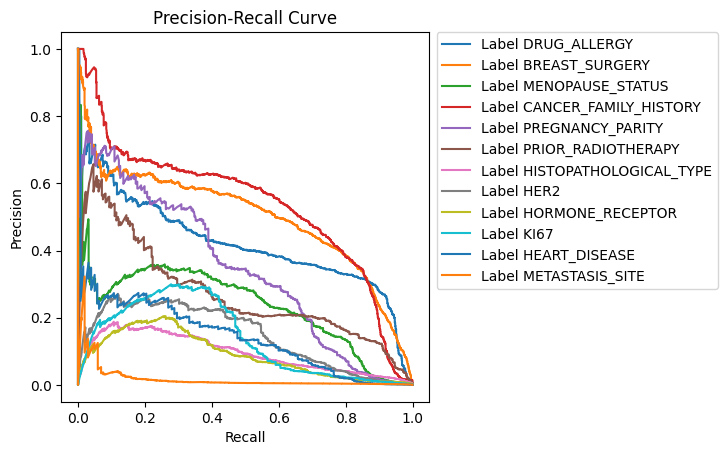

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.labels_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    plt.plot(recall, precision, label=label_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()

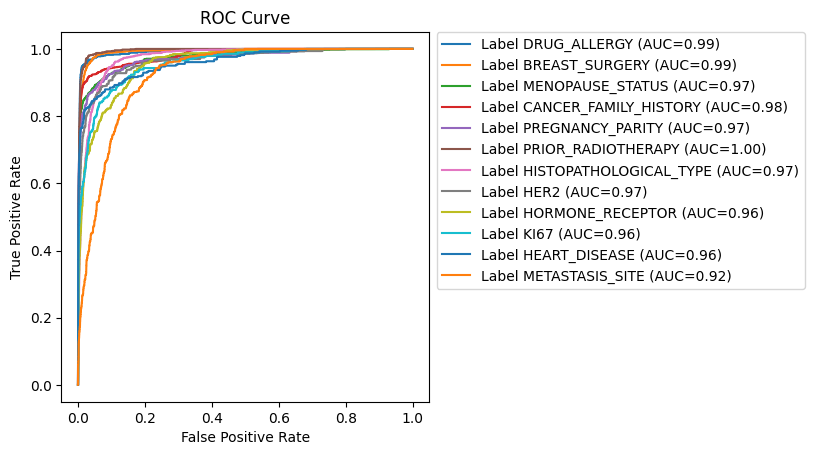

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot ROC curve for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.labels_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label_name} (AUC={auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()

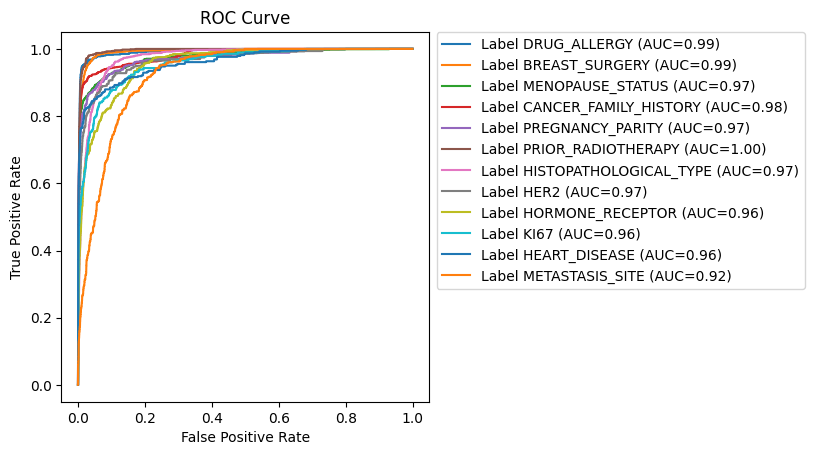

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

# Plot ROC curve for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.labels_to_consider[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label_name} (AUC={auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()